In [1]:
import pandas as pd
import numpy as np

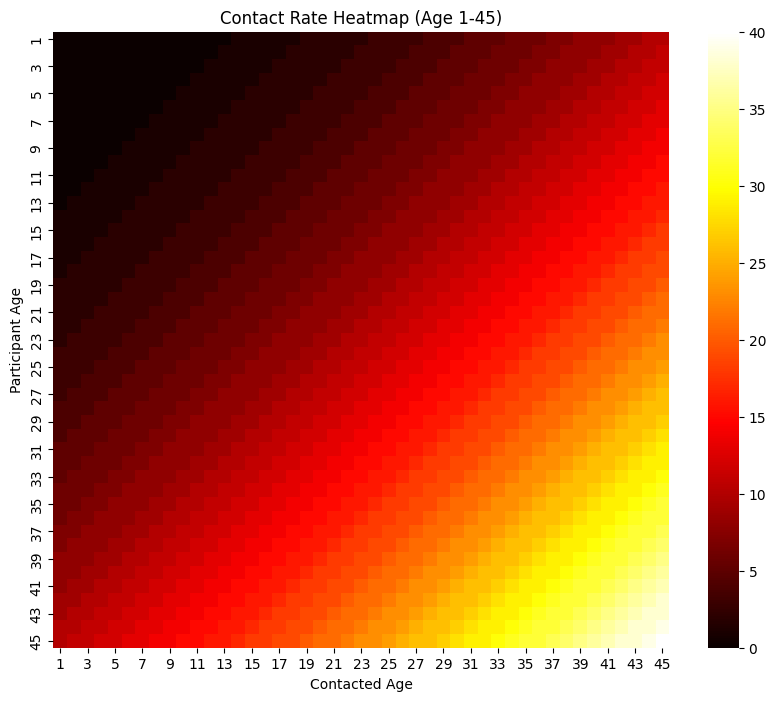

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Parameters
age_range = np.arange(1, 46)

# Create DataFrame for contact counts
data = []
for age_part in age_range:
    for age_cnt in age_range:
        # Define contact rate as a function of age sums (e.g., quadratic increase)
        contact_rate = (age_part + age_cnt) ** 2 // 199
        data.append([age_part, age_cnt, contact_rate])

contact_df = pd.DataFrame(data, columns=['age_part', 'age_cnt', 'y'])

# Pivot to create a heatmap matrix
heatmap_data = contact_df.pivot(index='age_part', columns='age_cnt', values='y')

# Plotting the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data, cmap='hot', square=True)
plt.title("Contact Rate Heatmap (Age 1-45)")
plt.xlabel("Contacted Age")
plt.ylabel("Participant Age")
plt.show()


In [ ]:
# True contact matrix

In [3]:
df = pd.DataFrame(data, columns=['age_part', 'age_cnt', 'y'])
df['id'] = np.arange(2025)

In [4]:
df['sex'] = df.id.apply(lambda x: str(x % 2))

In [5]:
df

,age_part,age_cnt,y,id,sex
0,1,1,0,0,0
1,1,2,0,1,1
2,1,3,0,2,0
3,1,4,0,3,1
4,1,5,0,4,0
...,...,...,...,...,...
2020,45,41,37,2020,0
2021,45,42,38,2021,1
2022,45,43,38,2022,0
2023,45,44,39,2023,1


In [6]:
np.random.seed(0)
for i in range(25):
    x = np.random.randint(200)
    df.loc[df.id==x, 'age_cnt'] = None

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2025 entries, 0 to 2024
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age_part  2025 non-null   int64  
 1   age_cnt   2002 non-null   float64
 2   y         2025 non-null   int64  
 3   id        2025 non-null   int64  
 4   sex       2025 non-null   object 
dtypes: float64(1), int64(3), object(1)
memory usage: 79.2+ KB


In [8]:
from cntmosaic.preprocess import impute_age_min_max, make_train_data

In [9]:
df

,age_part,age_cnt,y,id,sex
0,1,1.0,0,0,0
1,1,2.0,0,1,1
2,1,3.0,0,2,0
3,1,4.0,0,3,1
4,1,5.0,0,4,0
...,...,...,...,...,...
2020,45,41.0,37,2020,0
2021,45,42.0,38,2021,1
2022,45,43.0,38,2022,0
2023,45,44.0,39,2023,1


In [ ]:
heatmap_data =df.dropna().pivot(index='age_part', columns='age_cnt', values='y')

# Plotting the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data, cmap='hot', square=True)

In [10]:
df2 = make_train_data(df, 'id', grp_vars='sex')

/home/yiminglin/Downloads/cntmosaic/cntmosaic/preprocess/_preprocess.py:174: RuntimeWarning: Dropped 23 rows with missing values
  warnings.warn(f'Dropped {n_dropped} rows with missing values', RuntimeWarning)


In [11]:
df2

,age_part,age_cnt,sex,y,N
0,1,1,0,0,22
1,1,1,1,0,18
2,1,2,0,0,22
3,1,2,1,0,18
4,1,3,0,0,22
...,...,...,...,...,...
4045,45,43,1,0,22
4046,45,44,0,0,23
4047,45,44,1,39,22
4048,45,45,0,40,23


In [ ]:
df['z'] = np.random.randint(10, size=2025)

In [ ]:
from cntmosaic.preprocess import add_grp_cnt_offsets

df3 = add_grp_cnt_offsets(df2, df, 'sex')

In [ ]:
df3

In [13]:
from cntmosaic.models import BRCcustom

In [14]:
model = BRCcustom(df2, 1/ np.ones(45))

In [ ]:
from numpyro import distributions as dist

In [ ]:
model.add_prior('alpha', dist.InverseGamma(5, 5))

In [ ]:
model.add_prior('nu', dist.InverseGamma(5, 5).expand([2]))

In [ ]:
model.add_HSGP('alpha', 'nu')
model.add_prior('beta0', dist.Exponential(1))
model.add_intermediate('lograte=beta0+f')
model.add_intermediate('log_cint=lograte+log_P')

In [ ]:
model.intermediate

## sample from prior distribution

In [ ]:
model.prior['alpha']

In [ ]:
import jax

In [ ]:
key, subkey = jax.random.split(jax.random.PRNGKey(0))
samples = model.prior['alpha'].sample(subkey, sample_shape=(5,))

In [ ]:
samples

## Run MCMC

In [ ]:
model.set_age_dim(45)

In [ ]:
import jax
model.compile()
model.run_inference_mcmc(jax.random.PRNGKey(0),
    num_samples = 50,
    num_warmup = 50,
    num_chains = 1)